# Exp05. Free-form vs Mascot-preserving Constrained Patch

Standalone notebook for Exp05.

**Purpose**  
Compare the naturalness–effectiveness trade-off under the fixed worst-case tested setting found from Exp03–Exp04.

**Fixed setting**

- Model: AdaFace IR101 WebFace12M
- Dataset: Color LFW
- Location: `nose_bridge`
- Patch size ratio: `0.35`
- Patch size: `39×39` on 112×112 input
- Conditions:
  1. Normal mascot sticker
  2. Free-form adversarial patch
  3. Mascot-preserving constrained adversarial patch

This notebook is for controlled offline robustness evaluation using public data and pretrained models.

In [1]:
# ============================================================
# Cell 0. Dependency Installation
# ============================================================

INSTALL_DEPENDENCIES = True

if INSTALL_DEPENDENCIES:
    !pip -q uninstall -y transformers tokenizers huggingface_hub facenet-pytorch
    !pip -q install \
        "transformers==4.45.2" \
        "tokenizers>=0.20,<0.21" \
        "huggingface_hub>=0.23.2" \
        "safetensors" \
        "omegaconf" \
        "timm" \
        "fvcore" \
        "scikit-learn" \
        "matplotlib" \
        "pandas" \
        "tqdm"
    !pip -q install facenet-pytorch --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 157.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 78.9 MB/s eta 0:00:00


In [2]:
# ============================================================
# Cell 1. Imports, Config, Output Paths
# ============================================================

import os
import sys
import json
import math
import random
from pathlib import Path
from collections import defaultdict
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF

from sklearn.datasets import fetch_lfw_people
from huggingface_hub import snapshot_download
from transformers import AutoModel
from tqdm.auto import tqdm

from google.colab import drive
drive.mount("/content/drive")


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


# ------------------------------------------------------------
# Model config
# ------------------------------------------------------------

MODEL_NAME = "minchul/cvlface_adaface_ir101_webface12m"
MODEL_SHORT_NAME = "adaface_ir101_wf12m"


# ------------------------------------------------------------
# Dataset config
# ------------------------------------------------------------

NUM_IDENTITIES = 100
MIN_FACES_PER_PERSON = 5
ENROLL_IMAGES_PER_ID = 1
MAX_PROBES_PER_ID = 8
TARGET_FAR = 0.01

BATCH_SIZE = 64
NUM_WORKERS = 0


# ------------------------------------------------------------
# Mascot / sticker config
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive")

# 필요하면 여기만 수정
MASCOT_PATH = DRIVE_ROOT / "SafeAI-final-project/mask/puang.png"

EXP05_LOCATION = "nose_bridge"
EXP05_PATCH_SIZE_RATIO = 0.35
EXP05_PATCH_SIZE_PX = max(4, min(112, int(round(112 * EXP05_PATCH_SIZE_RATIO))))


# ------------------------------------------------------------
# Attack config
# ------------------------------------------------------------

ATTACK_STEPS = 1000
ATTACK_BATCH_SIZE = 32
ATTACK_LR = 0.05

TAU = 0.05
MARGIN = 0.05
THRESHOLD_MARGIN = 0.00

LAMBDA_TRUE = 1.0
LAMBDA_IMP = 2.0
LAMBDA_THRESH = 2.0
LAMBDA_RANK = 1.0
TV_WEIGHT = 0.0


# ------------------------------------------------------------
# Exp05 constrained patch config
# ------------------------------------------------------------
# normalized [-1, 1] 기준 epsilon
# RGB [0, 1] 기준으로는 epsilon / 2 만큼 변형 허용

EXP05_CONSTRAIN_EPS_NORM = 0.50
EXP05_PRESERVE_WEIGHT = 0.10
EXP05_DELTA_TV_WEIGHT = 0.01


# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------

RUN_TAG = datetime.now(
    ZoneInfo("Asia/Seoul")
).strftime("run_%Y%m%d_%H%M%S")

PROJECT_DRIVE_DIR = DRIVE_ROOT / "SafeAI-final-project" / "output"

RUN_ROOT = (
    PROJECT_DRIVE_DIR
    / "exp05_freeform_vs_constrained_only_color_lfw"
    / MODEL_SHORT_NAME
    / RUN_TAG
)

PREREQ_DIR = RUN_ROOT / "prereq_clean_baseline"
PROCESS_DIR = RUN_ROOT / "process_visuals"

EXP05_DIR = RUN_ROOT / "exp05_freeform_vs_constrained"
EXP05_DETAIL_DIR = EXP05_DIR / "details"
EXP05_FIG_DIR = EXP05_DIR / "figures"
EXP05_PATCH_DIR = EXP05_DIR / "patches"
EXP05_HISTORY_DIR = EXP05_DIR / "histories"

for d in [
    RUN_ROOT,
    PREREQ_DIR,
    PROCESS_DIR,
    EXP05_DIR,
    EXP05_DETAIL_DIR,
    EXP05_FIG_DIR,
    EXP05_PATCH_DIR,
    EXP05_HISTORY_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("RUN_TAG:", RUN_TAG)
print("RUN_ROOT:", RUN_ROOT)
print("MODEL_SHORT_NAME:", MODEL_SHORT_NAME)
print("EXP05_LOCATION:", EXP05_LOCATION)
print("EXP05_PATCH_SIZE_RATIO:", EXP05_PATCH_SIZE_RATIO)
print("EXP05_PATCH_SIZE_PX:", EXP05_PATCH_SIZE_PX)

if not Path(MASCOT_PATH).exists():
    raise FileNotFoundError(f"MASCOT_PATH가 존재하지 않음: {MASCOT_PATH}")

Mounted at /content/drive
DEVICE: cuda
RUN_TAG: run_20260615_145730
RUN_ROOT: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730
MODEL_SHORT_NAME: adaface_ir101_wf12m
EXP05_LOCATION: nose_bridge
EXP05_PATCH_SIZE_RATIO: 0.35
EXP05_PATCH_SIZE_PX: 39


In [3]:
# ============================================================
# Cell 2. Image Utilities
# ============================================================

preprocess = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])


def numpy_face_to_pil(img):
    """LFW numpy image를 RGB PIL image로 변환한다."""

    img = np.asarray(img)

    if img.ndim == 3 and img.shape[0] in [1, 3] and img.shape[-1] not in [1, 3]:
        img = np.transpose(img, (1, 2, 0))

    if np.issubdtype(img.dtype, np.floating):
        img = np.nan_to_num(img)

        if img.max() <= 1.5:
            img = img * 255.0

        img = np.clip(img, 0, 255).astype(np.uint8)
    else:
        img = np.clip(img, 0, 255).astype(np.uint8)

    if img.ndim == 2:
        return Image.fromarray(img, mode="L").convert("RGB")

    return Image.fromarray(img).convert("RGB")


def pil_to_model_tensor(pil):
    """PIL RGB image를 모델 입력 tensor로 변환한다."""

    return preprocess(pil.convert("RGB"))


def tensor_to_pil(x):
    """[-1, 1] tensor를 PIL RGB image로 변환한다."""

    x = x.detach().cpu().clamp(-1, 1)
    x = (x * 0.5 + 0.5).clamp(0, 1)

    return TF.to_pil_image(x)


def show_pil_grid(images, titles=None, ncols=5, figsize=(12, 6), save_path=None):
    """PIL image list를 grid로 출력하고 저장한다."""

    n = len(images)

    if n == 0:
        print("No images to show.")
        return

    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)

    plt.figure(figsize=figsize)

    for i, img in enumerate(images):
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(img)
        ax.axis("off")

        if titles is not None:
            ax.set_title(titles[i], fontsize=9)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()


def save_patch_png(patch, mask, path):
    """patch tensor와 alpha mask를 PNG로 저장한다."""

    patch = patch.detach().cpu().clamp(-1, 1)
    mask = mask.detach().cpu().clamp(0, 1)

    rgb = (patch[0] * 0.5 + 0.5).clamp(0, 1)
    alpha = mask[0].clamp(0, 1)

    rgba = torch.cat([rgb, alpha], dim=0)
    pil = TF.to_pil_image(rgba)

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    pil.save(path)

    print("Saved:", path)


def patch_to_display_pil(patch, mask, scale=5):
    """patch + alpha mask를 흰 배경 위에 올려서 보기 쉽게 만든다."""

    patch_cpu = patch.detach().cpu().clamp(-1, 1)
    mask_cpu = mask.detach().cpu().clamp(0, 1)

    rgb = (patch_cpu[0] * 0.5 + 0.5).clamp(0, 1)
    alpha = mask_cpu[0].clamp(0, 1)

    rgba = torch.cat([rgb, alpha], dim=0)
    rgba_pil = TF.to_pil_image(rgba)

    bg = Image.new("RGB", rgba_pil.size, "white")
    bg.paste(rgba_pil.convert("RGB"), mask=rgba_pil.getchannel("A"))

    if scale != 1:
        bg = bg.resize(
            (bg.width * scale, bg.height * scale),
            Image.NEAREST,
        )

    return bg

Enrollment images: 100
Probe images: 629
Identities: 100
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/prereq_clean_baseline/05_lfw_color_split_metadata.csv
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/process_visuals/05_raw_color_lfw_samples.png


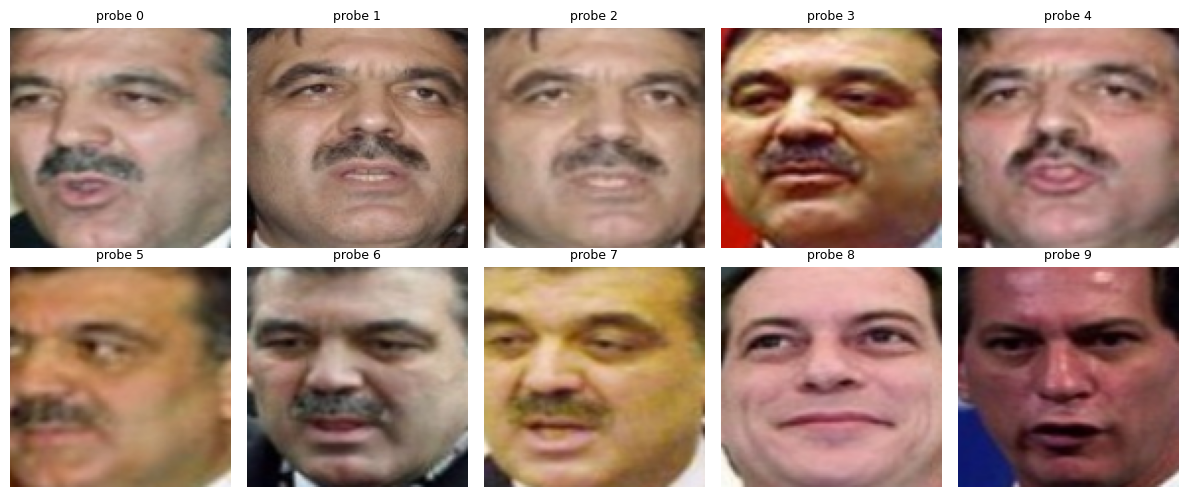

In [4]:
# ============================================================
# Cell 3. Load Color LFW
# ============================================================

# order = left_eye, right_eye, nose, left_mouth, right_mouth
CANONICAL_LANDMARKS_112 = np.array([
    [38.0, 42.0],
    [74.0, 42.0],
    [56.0, 60.0],
    [42.0, 78.0],
    [70.0, 78.0],
], dtype=np.float32)


class FaceDataset(Dataset):
    """LFW item list를 PyTorch Dataset으로 감싼다."""

    def __init__(self, items):
        self.items = list(items)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        landmarks = item.get("landmarks", CANONICAL_LANDMARKS_112)

        return {
            "image": pil_to_model_tensor(item["pil"]),
            "identity": item["identity"],
            "index": idx,
            "role": item.get("role", "unknown"),
            "local_index": item.get("local_index", -1),
            "lfw_index": item.get("lfw_index", -1),
            "landmarks": torch.tensor(landmarks, dtype=torch.float32),
            "landmark_source": item.get("landmark_source", "unknown"),
        }


def load_lfw_items(
    num_identities=NUM_IDENTITIES,
    min_faces_per_person=MIN_FACES_PER_PERSON,
):
    """컬러 LFW를 로드하고 enrollment/probe split을 구성한다."""

    lfw = fetch_lfw_people(
        min_faces_per_person=min_faces_per_person,
        resize=1.0,
        color=True,
        funneled=True,
    )

    by_id = defaultdict(list)

    for idx, img in enumerate(lfw.images):
        identity = str(lfw.target_names[lfw.target[idx]])
        pil = numpy_face_to_pil(img)

        by_id[identity].append({
            "identity": identity,
            "pil": pil,
            "lfw_index": idx,
        })

    eligible = [
        (identity, imgs)
        for identity, imgs in by_id.items()
        if len(imgs) >= ENROLL_IMAGES_PER_ID + 1
    ]

    eligible = sorted(eligible, key=lambda x: x[0])

    rng = np.random.default_rng(SEED)
    rng.shuffle(eligible)

    selected = eligible[:num_identities]

    enroll_items = []
    probe_items = []

    for identity, imgs in selected:
        imgs = list(imgs)
        rng.shuffle(imgs)

        enroll_imgs = imgs[:ENROLL_IMAGES_PER_ID]
        probe_imgs = imgs[
            ENROLL_IMAGES_PER_ID:
            ENROLL_IMAGES_PER_ID + MAX_PROBES_PER_ID
        ]

        for j, face_item in enumerate(enroll_imgs):
            enroll_items.append({
                "identity": identity,
                "pil": face_item["pil"],
                "lfw_index": face_item["lfw_index"],
                "role": "enroll",
                "local_index": j,
            })

        for j, face_item in enumerate(probe_imgs):
            probe_items.append({
                "identity": identity,
                "pil": face_item["pil"],
                "lfw_index": face_item["lfw_index"],
                "role": "probe",
                "local_index": j,
            })

    return enroll_items, probe_items


enroll_items, probe_items = load_lfw_items()

print("Enrollment images:", len(enroll_items))
print("Probe images:", len(probe_items))
print("Identities:", len(set([x["identity"] for x in enroll_items])))

# split metadata 저장
split_rows = []

for i, item in enumerate(enroll_items):
    split_rows.append({
        "dataset": "enroll",
        "row": i,
        "identity": item["identity"],
        "local_index": item["local_index"],
        "lfw_index": item["lfw_index"],
    })

for i, item in enumerate(probe_items):
    split_rows.append({
        "dataset": "probe",
        "row": i,
        "identity": item["identity"],
        "local_index": item["local_index"],
        "lfw_index": item["lfw_index"],
    })

split_df = pd.DataFrame(split_rows)
split_path = PREREQ_DIR / "05_lfw_color_split_metadata.csv"
split_df.to_csv(split_path, index=False)

print("Saved:", split_path)

# raw sample 저장
sample_items = probe_items[:10]
sample_imgs = [x["pil"].resize((112, 112)) for x in sample_items]
sample_titles = [f"probe {i}" for i in range(len(sample_items))]

show_pil_grid(
    sample_imgs,
    sample_titles,
    ncols=5,
    figsize=(12, 5),
    save_path=PROCESS_DIR / "05_raw_color_lfw_samples.png",
)

Detect landmarks for enroll_items:   0%|          | 0/100 [00:00<?, ?it/s]

enroll_items: mtcnn=99, fallback=1


Detect landmarks for probe_items:   0%|          | 0/629 [00:00<?, ?it/s]

probe_items: mtcnn=627, fallback=2
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/prereq_clean_baseline/05_landmark_metadata.csv
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/process_visuals/05_lfw_crop_to_landmark_process.png


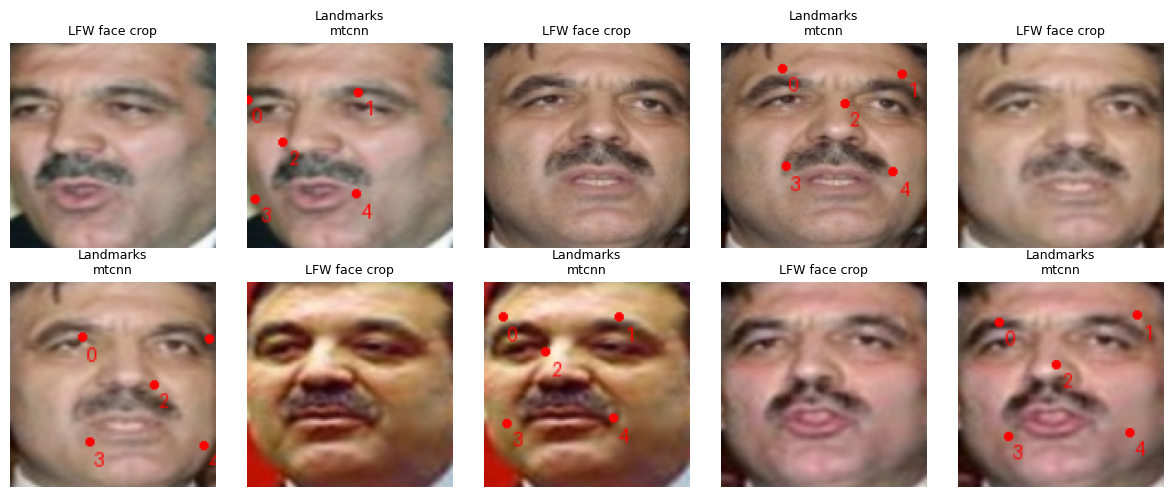

In [5]:
# ============================================================
# Cell 4. MTCNN Landmark Detection
# ============================================================

try:
    from facenet_pytorch import MTCNN
except ImportError:
    !pip -q install facenet-pytorch --no-deps
    from facenet_pytorch import MTCNN


USE_LANDMARK_BASED_PLACEMENT = True
LANDMARK_FALLBACK_TO_CANONICAL = True

LANDMARK_MTCNN = MTCNN(
    image_size=112,
    margin=0,
    keep_all=True,
    post_process=False,
    device=DEVICE,
)


def detect_landmarks_112(pil, detector=LANDMARK_MTCNN):
    """PIL face image에서 112x112 기준 5-point landmark를 추출한다."""

    img112 = pil.convert("RGB").resize((112, 112), Image.BILINEAR)

    try:
        boxes, probs, landmarks = detector.detect(img112, landmarks=True)
    except Exception:
        boxes, probs, landmarks = None, None, None

    if landmarks is not None and len(landmarks) > 0:
        if probs is None:
            best_idx = 0
            best_prob = np.nan
        else:
            probs_arr = np.asarray(probs, dtype=np.float32)
            valid = np.nan_to_num(probs_arr, nan=-1.0)
            best_idx = int(valid.argmax())
            best_prob = float(probs_arr[best_idx])

        lm = np.asarray(landmarks[best_idx], dtype=np.float32)

        if lm.shape == (5, 2) and np.isfinite(lm).all():
            lm[:, 0] = np.clip(lm[:, 0], 0, 111)
            lm[:, 1] = np.clip(lm[:, 1], 0, 111)

            box = None
            if boxes is not None and len(boxes) > best_idx:
                box = np.asarray(boxes[best_idx], dtype=np.float32)

            return lm, "mtcnn", best_prob, box

    if LANDMARK_FALLBACK_TO_CANONICAL:
        return CANONICAL_LANDMARKS_112.copy(), "canonical_fallback", np.nan, None

    raise RuntimeError("MTCNN landmark detection failed and fallback is disabled.")


def add_landmarks_to_items(items, desc="items"):
    """items에 landmarks, landmark_source, landmark_prob를 추가한다."""

    mtcnn_count = 0
    fallback_count = 0

    for item in tqdm(items, desc=f"Detect landmarks for {desc}"):
        landmarks, source, prob, box = detect_landmarks_112(item["pil"])

        item["landmarks"] = landmarks
        item["landmark_source"] = source
        item["landmark_prob"] = prob
        item["mtcnn_box"] = box

        if source == "mtcnn":
            mtcnn_count += 1
        else:
            fallback_count += 1

    print(f"{desc}: mtcnn={mtcnn_count}, fallback={fallback_count}")


def draw_landmarks_on_pil(pil, landmarks, radius=2):
    """landmark 점을 그린 이미지 반환한다."""

    img = pil.convert("RGB").resize((112, 112), Image.BILINEAR)
    draw = ImageDraw.Draw(img)

    for i, (x, y) in enumerate(np.asarray(landmarks)):
        draw.ellipse(
            [x - radius, y - radius, x + radius, y + radius],
            fill=(255, 0, 0),
        )
        draw.text((x + 3, y + 3), str(i), fill=(255, 0, 0))

    return img


add_landmarks_to_items(enroll_items, desc="enroll_items")
add_landmarks_to_items(probe_items, desc="probe_items")

enroll_ds = FaceDataset(enroll_items)
probe_ds = FaceDataset(probe_items)

# landmark metadata 저장
landmark_rows = []

for dataset_name, items in [("enroll", enroll_items), ("probe", probe_items)]:
    for i, item in enumerate(items):
        row = {
            "dataset": dataset_name,
            "row": i,
            "identity": item["identity"],
            "lfw_index": item["lfw_index"],
            "landmark_source": item.get("landmark_source", "unknown"),
            "landmark_prob": item.get("landmark_prob", np.nan),
        }

        lm = item["landmarks"]
        for j, name in enumerate(["left_eye", "right_eye", "nose", "left_mouth", "right_mouth"]):
            row[f"{name}_x"] = float(lm[j, 0])
            row[f"{name}_y"] = float(lm[j, 1])

        landmark_rows.append(row)

landmark_df = pd.DataFrame(landmark_rows)
landmark_path = PREREQ_DIR / "05_landmark_metadata.csv"
landmark_df.to_csv(landmark_path, index=False)
print("Saved:", landmark_path)

# landmark process figure
process_imgs = []
process_titles = []

for item in probe_items[:5]:
    raw = item["pil"].convert("RGB").resize((112, 112), Image.BILINEAR)
    lm_img = draw_landmarks_on_pil(item["pil"], item["landmarks"])

    process_imgs.extend([raw, lm_img])
    process_titles.extend([
        "LFW face crop",
        f"Landmarks\n{item['landmark_source']}",
    ])

show_pil_grid(
    process_imgs,
    process_titles,
    ncols=5,
    figsize=(12, 5),
    save_path=PROCESS_DIR / "05_lfw_crop_to_landmark_process.png",
)

In [6]:
# ============================================================
# Cell 5. Model Loader and Metrics
# ============================================================

MODEL_CACHE = {}


def load_cvlface_model(model_name: str, device: str = DEVICE):
    """CVLFace 모델을 로드한다."""

    if model_name in MODEL_CACHE:
        return MODEL_CACHE[model_name]

    local_path = snapshot_download(
        repo_id=model_name,
        local_dir=f"/content/{model_name.replace('/', '_')}",
        local_dir_use_symlinks=False,
    )

    if local_path not in sys.path:
        sys.path.insert(0, local_path)

    cwd = os.getcwd()
    os.chdir(local_path)

    try:
        model = AutoModel.from_pretrained(
            local_path,
            trust_remote_code=True,
            torch_dtype=torch.float32,
            local_files_only=True,
        )
    finally:
        os.chdir(cwd)

    model = model.to(device).eval()

    for p in model.parameters():
        p.requires_grad_(False)

    MODEL_CACHE[model_name] = (model, local_path)

    print("Loaded:", model_name)
    print("Local path:", local_path)

    return model, local_path


def forward_embedding(model, x):
    """모델 출력에서 face embedding을 추출하고 L2 normalize한다."""

    out = model(x)

    if isinstance(out, dict):
        for key in ["embeddings", "embedding", "last_hidden_state", "pooler_output"]:
            if key in out:
                out = out[key]
                break

    if isinstance(out, (tuple, list)):
        out = out[0]

    if out.ndim > 2:
        out = torch.flatten(out, start_dim=1)

    return F.normalize(out.float(), p=2, dim=1)


@torch.no_grad()
def extract_embeddings(model, dataset, batch_size=BATCH_SIZE):
    """Dataset 전체 embedding을 추출한다."""

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    embs = []
    ids = []
    indices = []

    for batch in tqdm(loader, desc="Extract embeddings"):
        x = batch["image"].to(DEVICE)
        emb = forward_embedding(model, x).cpu()

        embs.append(emb)
        ids.extend(list(batch["identity"]))

        batch_indices = batch["index"]

        if torch.is_tensor(batch_indices):
            batch_indices = batch_indices.cpu().numpy().tolist()

        indices.extend(batch_indices)

    embs = torch.cat(embs, dim=0)

    return embs, ids, indices


def build_enrollment_db(enroll_embs, enroll_ids):
    """identity별 enrollment embedding 평균으로 DB를 구성한다."""

    by_id = defaultdict(list)

    for emb, identity in zip(enroll_embs, enroll_ids):
        by_id[identity].append(emb)

    db_ids = sorted(by_id.keys())
    db_embs = []

    for identity in db_ids:
        emb = torch.stack(by_id[identity], dim=0).mean(dim=0)
        emb = F.normalize(emb, p=2, dim=0)
        db_embs.append(emb)

    db_embs = torch.stack(db_embs, dim=0)

    return db_embs, db_ids


def compute_threshold_from_impostors(sim_mat, probe_ids, db_ids, target_far=TARGET_FAR):
    """Impostor similarity 분포에서 FAR 기준 threshold를 계산한다."""

    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}

    impostor_sims = []

    for i, identity in enumerate(probe_ids):
        true_idx = id_to_db_idx[identity]

        mask = np.ones(len(db_ids), dtype=bool)
        mask[true_idx] = False

        impostor_sims.extend(sim_mat[i, mask].tolist())

    impostor_sims = np.array(impostor_sims, dtype=np.float32)

    threshold = float(np.quantile(impostor_sims, 1.0 - target_far))
    actual_far = float((impostor_sims >= threshold).mean())

    return threshold, actual_far, impostor_sims


def compute_facepay_metrics(embs, ids, db_embs, db_ids, threshold):
    """Identification -> verification metric을 계산한다."""

    sim_mat = (embs @ db_embs.T).cpu().numpy()

    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}

    true_indices = np.array([id_to_db_idx[i] for i in ids])
    top1_indices = sim_mat.argmax(axis=1)

    top1_sims = sim_mat[np.arange(len(ids)), top1_indices]
    true_sims = sim_mat[np.arange(len(ids)), true_indices]

    top1_correct = top1_indices == true_indices
    accepted = top1_sims >= threshold

    correct_accept = top1_correct & accepted
    false_reject = ~accepted
    misidentified = ~top1_correct
    misaccept = misidentified & accepted

    metrics = {
        "n": int(len(ids)),
        "rank1_acc": float(top1_correct.mean()),
        "correct_accept_rate": float(correct_accept.mean()),
        "false_reject_rate": float(false_reject.mean()),
        "misid_rate": float(misidentified.mean()),
        "misaccept_rate": float(misaccept.mean()),
        "avg_top1_sim": float(top1_sims.mean()),
        "avg_true_sim": float(true_sims.mean()),
        "threshold": float(threshold),
    }

    detail = pd.DataFrame({
        "probe_row": np.arange(len(ids)),
        "identity": ids,
        "true_db_idx": true_indices,
        "top1_db_idx": top1_indices,
        "top1_identity": [db_ids[i] for i in top1_indices],
        "top1_similarity": top1_sims,
        "true_similarity": true_sims,
        "rank1_correct": top1_correct,
        "accepted": accepted,
        "correct_accept": correct_accept,
        "false_reject": false_reject,
        "misidentified": misidentified,
        "misaccept": misaccept,
    })

    return metrics, detail, sim_mat

In [7]:
# ============================================================
# Cell 6. Clean Baseline for Exp05 Prerequisite
# ============================================================

print("\n" + "=" * 80)
print("Prerequisite. Clean baseline")
print("=" * 80)

model, model_path = load_cvlface_model(MODEL_NAME)

enroll_embs_raw, enroll_ids_raw, enroll_indices = extract_embeddings(
    model,
    enroll_ds,
)

db_embs, db_ids = build_enrollment_db(
    enroll_embs_raw,
    enroll_ids_raw,
)

probe_embs, probe_ids, probe_indices = extract_embeddings(
    model,
    probe_ds,
)

clean_sim_mat = (probe_embs @ db_embs.T).cpu().numpy()

threshold, actual_far, impostor_sims = compute_threshold_from_impostors(
    clean_sim_mat,
    probe_ids,
    db_ids,
    target_far=TARGET_FAR,
)

clean_metrics, clean_detail_df, _ = compute_facepay_metrics(
    probe_embs,
    probe_ids,
    db_embs,
    db_ids,
    threshold,
)

clean_eval_mask = (
    clean_detail_df["rank1_correct"].values
    & clean_detail_df["accepted"].values
)

clean_eval_indices = (
    clean_detail_df.loc[clean_eval_mask, "probe_row"]
    .astype(int)
    .tolist()
)

clean_metrics.update({
    "model_name": MODEL_NAME,
    "model_short_name": MODEL_SHORT_NAME,
    "model_path": model_path,
    "target_far": TARGET_FAR,
    "actual_far": actual_far,
    "n_identities": len(db_ids),
    "n_enroll": len(enroll_ds),
    "n_probe": len(probe_ds),
    "clean_eval_n": len(clean_eval_indices),
    "lfw_color": True,
    "lfw_funneled": True,
    "run_tag": RUN_TAG,
})

summary_df = pd.DataFrame([clean_metrics])

summary_path = PREREQ_DIR / "05_prereq_clean_color_lfw_baseline_summary.csv"
detail_path = PREREQ_DIR / "05_prereq_clean_color_lfw_detail.csv"
clean_eval_path = PREREQ_DIR / "05_clean_eval_indices.csv"

summary_df.to_csv(summary_path, index=False)
clean_detail_df.to_csv(detail_path, index=False)

clean_eval_df = pd.DataFrame({
    "probe_row": clean_eval_indices,
    "identity": [probe_items[i]["identity"] for i in clean_eval_indices],
    "local_index": [probe_items[i]["local_index"] for i in clean_eval_indices],
    "lfw_index": [probe_items[i]["lfw_index"] for i in clean_eval_indices],
})

clean_eval_df.to_csv(clean_eval_path, index=False)

torch.save(db_embs, PREREQ_DIR / "db_embs.pt")
torch.save(probe_embs, PREREQ_DIR / "probe_embs.pt")

with open(PREREQ_DIR / "db_ids.json", "w", encoding="utf-8") as f:
    json.dump(db_ids, f, ensure_ascii=False, indent=2)

with open(PREREQ_DIR / "probe_ids.json", "w", encoding="utf-8") as f:
    json.dump(probe_ids, f, ensure_ascii=False, indent=2)

with open(PREREQ_DIR / "threshold.json", "w", encoding="utf-8") as f:
    json.dump({
        "target_far": TARGET_FAR,
        "actual_far": actual_far,
        "threshold": threshold,
    }, f, ensure_ascii=False, indent=2)

print("Threshold:", threshold)
print("Actual FAR:", actual_far)
print("Clean eval probes:", len(clean_eval_indices))
print("Saved:", summary_path)

display(summary_df)


Prerequisite. Clean baseline


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

example.yaml:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

...

Loaded iResNet model
compatible keys in state_dict 917 / 917
Check


<All keys matched successfully>
Loaded pretrained model from pretrained_model/model.pt
Loaded: minchul/cvlface_adaface_ir101_webface12m
Local path: /content/minchul_cvlface_adaface_ir101_webface12m


Extract embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

Extract embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

Threshold: 0.16163350641727448
Actual FAR: 0.010004657063480592
Clean eval probes: 614
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/prereq_clean_baseline/05_prereq_clean_color_lfw_baseline_summary.csv


,n,rank1_acc,correct_accept_rate,false_reject_rate,misid_rate,misaccept_rate,avg_top1_sim,avg_true_sim,threshold,model_name,...,model_path,target_far,actual_far,n_identities,n_enroll,n_probe,clean_eval_n,lfw_color,lfw_funneled,run_tag
0,629,0.976153,0.976153,0.00318,0.023847,0.020668,0.491778,0.490452,0.161634,minchul/cvlface_adaface_ir101_webface12m,...,/content/minchul_cvlface_adaface_ir101_webface12m,0.01,0.010005,100,100,629,614,True,True,run_20260615_145730


In [8]:
# ============================================================
# Cell 7. Sticker Placement Utilities
# ============================================================

LOCATION_CENTERS = {
    "forehead": (56, 30),
    "nose_bridge": (56, 45),
    "center": (56, 56),
    "nose": (56, 60),

    "left_cheek": (42, 66),
    "right_cheek": (70, 66),

    "left_under_eye": (43, 52),
    "right_under_eye": (69, 52),
    "under_eye": (56, 52),

    "mouth": (56, 76),
    "chin": (56, 88),
}


def get_patch_size_px(patch_size_ratio, image_size=112):
    """얼굴 입력 크기 기준 patch px를 계산한다."""

    return max(4, min(image_size, int(round(image_size * float(patch_size_ratio)))))


def get_landmark_based_centers(landmarks, location, image_size=112):
    """5-point landmark 기준 location별 patch center를 계산한다."""

    if location not in LOCATION_CENTERS:
        raise ValueError(f"Unknown location: {location}")

    lm = landmarks

    if not torch.is_tensor(lm):
        lm = torch.tensor(lm, dtype=torch.float32)

    lm = lm.float()

    if lm.ndim == 2:
        lm = lm.unsqueeze(0)

    if lm.ndim != 3 or lm.shape[1:] != (5, 2):
        raise ValueError(f"landmarks must be [B,5,2] or [5,2], got {tuple(lm.shape)}")

    left_eye = lm[:, 0, :]
    right_eye = lm[:, 1, :]
    nose = lm[:, 2, :]
    left_mouth = lm[:, 3, :]
    right_mouth = lm[:, 4, :]

    eye_mid = (left_eye + right_eye) / 2.0
    mouth_mid = (left_mouth + right_mouth) / 2.0

    eye_dist = torch.linalg.norm(
        right_eye - left_eye,
        dim=1,
        keepdim=True,
    ).clamp(min=8.0)

    if location == "nose_bridge":
        center = 0.55 * eye_mid + 0.45 * nose

    elif location in ["center", "nose"]:
        center = nose

    elif location == "forehead":
        center = eye_mid + 0.75 * (eye_mid - nose)

    elif location == "left_under_eye":
        center = 0.65 * left_eye + 0.35 * nose

    elif location == "right_under_eye":
        center = 0.65 * right_eye + 0.35 * nose

    elif location == "under_eye":
        left_center = 0.65 * left_eye + 0.35 * nose
        right_center = 0.65 * right_eye + 0.35 * nose
        center = (left_center + right_center) / 2.0

    elif location == "left_cheek":
        center = 0.35 * left_eye + 0.65 * left_mouth
        center = center + torch.cat(
            [-0.22 * eye_dist, -0.03 * eye_dist],
            dim=1,
        )

    elif location == "right_cheek":
        center = 0.35 * right_eye + 0.65 * right_mouth
        center = center + torch.cat(
            [0.22 * eye_dist, -0.03 * eye_dist],
            dim=1,
        )

    elif location == "mouth":
        center = mouth_mid

    elif location == "chin":
        center = mouth_mid + 0.80 * (mouth_mid - nose)

    else:
        fixed = torch.tensor(
            LOCATION_CENTERS[location],
            dtype=lm.dtype,
            device=lm.device,
        )
        center = fixed[None, :].expand(lm.shape[0], -1)

    center[:, 0] = center[:, 0].clamp(0, image_size - 1)
    center[:, 1] = center[:, 1].clamp(0, image_size - 1)

    return center


def centers_to_top_lefts(centers, patch_size_px, image_size=112):
    """center 좌표를 top-left 좌표로 변환한다."""

    x0 = torch.round(centers[:, 0] - patch_size_px / 2.0).long()
    y0 = torch.round(centers[:, 1] - patch_size_px / 2.0).long()

    x0 = x0.clamp(0, image_size - patch_size_px)
    y0 = y0.clamp(0, image_size - patch_size_px)

    return torch.stack([x0, y0], dim=1)


def get_patch_top_lefts(
    location,
    patch_size_px,
    batch_size,
    image_size=112,
    landmarks=None,
    device=DEVICE,
):
    """landmark-relative patch top-left 좌표를 계산한다."""

    if USE_LANDMARK_BASED_PLACEMENT and landmarks is not None:
        centers = get_landmark_based_centers(
            landmarks,
            location,
            image_size=image_size,
        ).to(device)

        return centers_to_top_lefts(
            centers,
            patch_size_px,
            image_size=image_size,
        )

    cx, cy = LOCATION_CENTERS[location]

    x0 = int(round(cx - patch_size_px / 2))
    y0 = int(round(cy - patch_size_px / 2))

    x0 = max(0, min(image_size - patch_size_px, x0))
    y0 = max(0, min(image_size - patch_size_px, y0))

    return torch.tensor(
        [[x0, y0]],
        dtype=torch.long,
        device=device,
    ).expand(batch_size, -1)


def load_mascot_patch_and_mask(patch_size_px, mascot_path=MASCOT_PATH, device=DEVICE):
    """마스코트 PNG를 patch tensor와 alpha mask로 변환한다."""

    if not Path(mascot_path).exists():
        raise FileNotFoundError(f"마스코트 파일 없음: {mascot_path}")

    img = Image.open(mascot_path).convert("RGBA")
    img = img.resize((patch_size_px, patch_size_px), Image.BILINEAR)

    arr = np.asarray(img).astype(np.float32) / 255.0

    rgb = arr[:, :, :3]
    alpha = arr[:, :, 3:4]

    patch = torch.tensor(rgb).permute(2, 0, 1).unsqueeze(0)
    patch = patch * 2.0 - 1.0

    mask = torch.tensor(alpha).permute(2, 0, 1).unsqueeze(0)
    mask = mask[:, :1].clamp(0, 1)

    return patch.to(device).float(), mask.to(device).float()


def apply_patch_tensor(
    x,
    patch,
    mask,
    location=EXP05_LOCATION,
    landmarks=None,
):
    """x에 patch를 landmark-relative 위치로 붙인다."""

    B, C, H, W = x.shape
    image_size = min(H, W)
    P = patch.shape[-1]

    top_lefts = get_patch_top_lefts(
        location=location,
        patch_size_px=P,
        batch_size=B,
        image_size=image_size,
        landmarks=landmarks,
        device=x.device,
    )

    x_adv = x.clone()

    patch_b = patch.to(x.device, dtype=x.dtype)
    mask_b = mask.to(x.device, dtype=x.dtype)

    for i in range(B):
        x0 = int(top_lefts[i, 0].item())
        y0 = int(top_lefts[i, 1].item())

        region = x_adv[i:i + 1, :, y0:y0 + P, x0:x0 + P]

        patched_region = (
            region * (1.0 - mask_b)
            + patch_b * mask_b
        )

        x_adv[i:i + 1, :, y0:y0 + P, x0:x0 + P] = patched_region

    return x_adv


def add_patch_to_pil_for_visual(
    pil,
    patch,
    mask,
    location,
    landmarks=None,
):
    """시각화용 PIL 이미지에 patch를 붙인다."""

    x = pil_to_model_tensor(pil).unsqueeze(0).to(DEVICE)

    lm = None
    if landmarks is not None:
        lm = torch.tensor(
            landmarks,
            dtype=torch.float32,
            device=DEVICE,
        ).unsqueeze(0)

    y = apply_patch_tensor(
        x,
        patch=patch.to(DEVICE),
        mask=mask.to(DEVICE),
        location=location,
        landmarks=lm,
    )

    return tensor_to_pil(y[0])

In [9]:
# ============================================================
# Cell 8. Evaluation and Optimization Utilities
# ============================================================

class IndexedSubsetDataset(Dataset):
    """clean-correct accepted subset만 공격 평가에 사용한다."""

    def __init__(self, base_ds, indices):
        self.base_ds = base_ds
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = self.indices[idx]
        item = dict(self.base_ds[base_idx])
        item["base_probe_row"] = base_idx
        return item


eval_ds = IndexedSubsetDataset(probe_ds, clean_eval_indices)

print("Eval subset size:", len(eval_ds))


@torch.no_grad()
def extract_embeddings_with_patch(
    model,
    dataset,
    patch=None,
    mask=None,
    location=EXP05_LOCATION,
    batch_size=BATCH_SIZE,
    desc="Eval",
):
    """patch optional embedding 추출."""

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    embs = []
    ids = []
    base_probe_rows = []

    for batch in tqdm(loader, desc=desc):
        x = batch["image"].to(DEVICE)

        landmarks = batch.get("landmarks", None)
        if landmarks is not None:
            landmarks = landmarks.to(DEVICE)

        if patch is not None and mask is not None:
            x = apply_patch_tensor(
                x,
                patch=patch,
                mask=mask,
                location=location,
                landmarks=landmarks,
            )

        emb = forward_embedding(model, x).cpu()

        embs.append(emb)
        ids.extend(list(batch["identity"]))

        rows = batch.get("base_probe_row", batch.get("index", None))

        if rows is None:
            rows = torch.arange(len(ids) - len(batch["identity"]), len(ids))

        if torch.is_tensor(rows):
            rows = rows.cpu().numpy().tolist()

        base_probe_rows.extend(rows)

    embs = torch.cat(embs, dim=0)

    return embs, ids, base_probe_rows


def evaluate_condition(
    condition_name,
    dataset,
    patch=None,
    mask=None,
    location=EXP05_LOCATION,
    patch_size_ratio=None,
    patch_size_px=None,
    save_detail_path=None,
):
    """조건별 metric과 detail을 계산한다."""

    embs, ids, base_probe_rows = extract_embeddings_with_patch(
        model=model,
        dataset=dataset,
        patch=patch,
        mask=mask,
        location=location,
        desc=f"Eval {condition_name} {location}",
    )

    metrics, detail, _ = compute_facepay_metrics(
        embs=embs,
        ids=ids,
        db_embs=db_embs,
        db_ids=db_ids,
        threshold=threshold,
    )

    clean_true_map = clean_detail_df.set_index("probe_row")["true_similarity"].to_dict()
    before_true = np.array([clean_true_map[i] for i in base_probe_rows])
    after_true = detail["true_similarity"].values

    metrics.update({
        "model_short_name": MODEL_SHORT_NAME,
        "model_name": MODEL_NAME,
        "condition": condition_name,
        "placement": "landmark_relative" if USE_LANDMARK_BASED_PLACEMENT else "fixed_coordinate",
        "location": location,
        "patch_size_ratio": float(patch_size_ratio) if patch_size_ratio is not None else np.nan,
        "patch_size_px": int(patch_size_px) if patch_size_px is not None else -1,
        "threshold": float(threshold),
        "avg_similarity_drop": float((before_true - after_true).mean()),
        "run_tag": RUN_TAG,
    })

    detail["model_short_name"] = MODEL_SHORT_NAME
    detail["condition"] = condition_name
    detail["placement"] = metrics["placement"]
    detail["location"] = location
    detail["patch_size_ratio"] = metrics["patch_size_ratio"]
    detail["patch_size_px"] = metrics["patch_size_px"]
    detail["base_probe_row"] = base_probe_rows
    detail["similarity_drop_from_clean"] = before_true - after_true

    if save_detail_path is not None:
        save_detail_path = Path(save_detail_path)
        save_detail_path.parent.mkdir(parents=True, exist_ok=True)
        detail.to_csv(save_detail_path, index=False)
        print("Saved detail:", save_detail_path)

    return metrics, detail


def total_variation_loss(patch, mask=None):
    """TV regularization loss를 계산한다."""

    if mask is not None:
        patch = patch * mask

    dx = torch.mean(torch.abs(patch[:, :, :, 1:] - patch[:, :, :, :-1]))
    dy = torch.mean(torch.abs(patch[:, :, 1:, :] - patch[:, :, :-1, :]))

    return dx + dy


def optimize_adversarial_sticker(
    model,
    dataset,
    db_embs,
    db_ids,
    init_patch,
    shape_mask,
    location,
    patch_size_ratio,
    patch_size_px,
    steps=ATTACK_STEPS,
    batch_size=ATTACK_BATCH_SIZE,
    lr=ATTACK_LR,
):
    """free-form soft threshold-aware adversarial sticker를 최적화한다."""

    db_t = db_embs.to(DEVICE)
    threshold_t = torch.tensor(float(threshold), device=DEVICE)

    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}

    patch = init_patch.clone().detach().to(DEVICE)
    mask = shape_mask.clone().detach().to(DEVICE)

    patch.requires_grad_(True)

    optimizer = torch.optim.Adam([patch], lr=lr)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )

    history = []
    step_iter = 0

    pbar = tqdm(
        total=steps,
        desc=f"Optimize free-form {location}, size={patch_size_ratio:.2f}",
    )

    while step_iter < steps:
        for batch in loader:
            if step_iter >= steps:
                break

            x = batch["image"].to(DEVICE)
            ids = list(batch["identity"])

            landmarks = batch.get("landmarks", None)
            if landmarks is not None:
                landmarks = landmarks.to(DEVICE)

            true_idx = torch.tensor(
                [id_to_db_idx[i] for i in ids],
                dtype=torch.long,
                device=DEVICE,
            )

            patched_x = apply_patch_tensor(
                x,
                patch=patch.clamp(-1, 1),
                mask=mask,
                location=location,
                landmarks=landmarks,
            )

            emb = forward_embedding(model, patched_x)
            sim = emb @ db_t.T

            batch_arange = torch.arange(sim.shape[0], device=DEVICE)

            true_sim = sim[batch_arange, true_idx]

            sim_other = sim.clone()
            sim_other[batch_arange, true_idx] = -1e9

            max_impostor_sim, _ = sim_other.max(dim=1)
            soft_impostor_sim = TAU * torch.logsumexp(sim_other / TAU, dim=1)

            loss_true = true_sim.mean()
            loss_imp = -soft_impostor_sim.mean()

            loss_thresh = torch.relu(
                threshold_t + THRESHOLD_MARGIN - soft_impostor_sim
            ).mean()

            loss_rank = torch.relu(
                true_sim - soft_impostor_sim + MARGIN
            ).mean()

            tv = total_variation_loss(patch, mask)

            attack_loss = (
                LAMBDA_TRUE * loss_true
                + LAMBDA_IMP * loss_imp
                + LAMBDA_THRESH * loss_thresh
                + LAMBDA_RANK * loss_rank
            )

            loss = attack_loss + TV_WEIGHT * tv

            optimizer.zero_grad()
            loss.backward()

            grad_norm = (
                patch.grad.detach().abs().mean().item()
                if patch.grad is not None
                else 0.0
            )

            optimizer.step()

            with torch.no_grad():
                patch.clamp_(-1, 1)

            if step_iter % 10 == 0 or step_iter == steps - 1:
                with torch.no_grad():
                    row = {
                        "step": step_iter,
                        "location": location,
                        "patch_size_ratio": float(patch_size_ratio),
                        "patch_size_px": int(patch_size_px),
                        "loss": float(loss.detach().cpu()),
                        "attack_loss": float(attack_loss.detach().cpu()),
                        "loss_true": float(loss_true.detach().cpu()),
                        "loss_imp": float(loss_imp.detach().cpu()),
                        "loss_thresh": float(loss_thresh.detach().cpu()),
                        "loss_rank": float(loss_rank.detach().cpu()),
                        "tv": float(tv.detach().cpu()),
                        "true_sim": float(true_sim.mean().detach().cpu()),
                        "soft_impostor_sim": float(soft_impostor_sim.mean().detach().cpu()),
                        "max_impostor_sim": float(max_impostor_sim.mean().detach().cpu()),
                        "gap_true_minus_impostor": float((true_sim - max_impostor_sim).mean().detach().cpu()),
                        "frac_imp_over_threshold": float((max_impostor_sim > threshold_t).float().mean().detach().cpu()),
                        "frac_misrank": float((max_impostor_sim > true_sim).float().mean().detach().cpu()),
                        "grad_norm": float(grad_norm),
                    }

                    history.append(row)

                    pbar.set_postfix({
                        "loss": row["loss"],
                        "true": row["true_sim"],
                        "imp": row["max_impostor_sim"],
                        "misrank": row["frac_misrank"],
                    })

            step_iter += 1
            pbar.update(1)

    pbar.close()

    return patch.detach().clamp(-1, 1), mask, pd.DataFrame(history)

Eval subset size: 614


In [10]:
# ============================================================
# Cell 9. Exp05 Helper Functions
# ============================================================

def compute_patch_preservation_metrics(
    patch,
    base_patch,
    mask,
    condition_name,
):
    """
    base mascot과 현재 patch의 시각적 차이를 계산한다.
    - RGB [0, 1] 기준
    - alpha mask가 있는 영역만 평가한다.
    """

    patch_rgb = (patch.detach().cpu().clamp(-1, 1) * 0.5 + 0.5).clamp(0, 1)
    base_rgb = (base_patch.detach().cpu().clamp(-1, 1) * 0.5 + 0.5).clamp(0, 1)
    mask_cpu = mask.detach().cpu().clamp(0, 1)

    visible = (mask_cpu > 0.05).float()

    denom = visible.sum().item() * 3.0 + 1e-8

    diff = (patch_rgb - base_rgb) * visible
    abs_diff = diff.abs()

    mse = float((diff ** 2).sum().item() / denom)
    rmse = float(math.sqrt(mse))
    mae = float(abs_diff.sum().item() / denom)
    linf = float(abs_diff.max().item())

    if mse <= 1e-12:
        psnr = float("inf")
    else:
        psnr = float(20.0 * math.log10(1.0 / math.sqrt(mse)))

    return {
        "condition": condition_name,
        "patch_mae_rgb_0_1": mae,
        "patch_rmse_rgb_0_1": rmse,
        "patch_linf_rgb_0_1": linf,
        "patch_linf_rgb_255": linf * 255.0,
        "patch_psnr_visible": psnr,
        "visible_alpha_ratio": float(visible.mean().item()),
    }


def optimize_mascot_preserving_sticker(
    model,
    dataset,
    db_embs,
    db_ids,
    base_patch,
    shape_mask,
    location,
    patch_size_ratio,
    patch_size_px,
    eps_norm=EXP05_CONSTRAIN_EPS_NORM,
    preserve_weight=EXP05_PRESERVE_WEIGHT,
    delta_tv_weight=EXP05_DELTA_TV_WEIGHT,
    steps=ATTACK_STEPS,
    batch_size=ATTACK_BATCH_SIZE,
    lr=ATTACK_LR,
):
    """
    mascot-preserving constrained adversarial sticker를 최적화한다.

    핵심 제약:
    - patch는 base mascot 주변 epsilon 범위 안에만 존재한다.
    - alpha mask 바깥은 base mascot으로 유지한다.
    - preserve loss로 base mascot과의 차이를 추가로 억제한다.
    """

    db_t = db_embs.to(DEVICE)
    threshold_t = torch.tensor(float(threshold), device=DEVICE)

    id_to_db_idx = {
        identity: i
        for i, identity in enumerate(db_ids)
    }

    base = base_patch.clone().detach().to(DEVICE)
    mask = shape_mask.clone().detach().to(DEVICE)

    patch = base.clone().detach()
    patch.requires_grad_(True)

    lower = (base - eps_norm).clamp(-1, 1)
    upper = (base + eps_norm).clamp(-1, 1)

    optimizer = torch.optim.Adam([patch], lr=lr)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )

    history = []
    step_iter = 0

    pbar = tqdm(
        total=steps,
        desc=f"Optimize constrained {location}, size={patch_size_ratio:.2f}",
    )

    while step_iter < steps:
        for batch in loader:
            if step_iter >= steps:
                break

            x = batch["image"].to(DEVICE)
            ids = list(batch["identity"])

            landmarks = batch.get("landmarks", None)
            if landmarks is not None:
                landmarks = landmarks.to(DEVICE)

            true_idx = torch.tensor(
                [id_to_db_idx[i] for i in ids],
                dtype=torch.long,
                device=DEVICE,
            )

            patched_x = apply_patch_tensor(
                x,
                patch=patch.clamp(-1, 1),
                mask=mask,
                location=location,
                landmarks=landmarks,
            )

            emb = forward_embedding(model, patched_x)
            sim = emb @ db_t.T

            batch_arange = torch.arange(sim.shape[0], device=DEVICE)
            true_sim = sim[batch_arange, true_idx]

            sim_other = sim.clone()
            sim_other[batch_arange, true_idx] = -1e9

            max_impostor_sim, _ = sim_other.max(dim=1)
            soft_impostor_sim = TAU * torch.logsumexp(sim_other / TAU, dim=1)

            loss_true = true_sim.mean()
            loss_imp = -soft_impostor_sim.mean()

            loss_thresh = torch.relu(
                threshold_t + THRESHOLD_MARGIN - soft_impostor_sim
            ).mean()

            loss_rank = torch.relu(
                true_sim - soft_impostor_sim + MARGIN
            ).mean()

            attack_loss = (
                LAMBDA_TRUE * loss_true
                + LAMBDA_IMP * loss_imp
                + LAMBDA_THRESH * loss_thresh
                + LAMBDA_RANK * loss_rank
            )

            preserve_loss = (((patch - base) ** 2) * mask).sum() / (
                mask.sum() * patch.shape[1] + 1e-8
            )

            delta_tv = total_variation_loss(patch - base, mask)

            loss = (
                attack_loss
                + preserve_weight * preserve_loss
                + delta_tv_weight * delta_tv
            )

            optimizer.zero_grad()
            loss.backward()

            grad_norm = (
                patch.grad.detach().abs().mean().item()
                if patch.grad is not None
                else 0.0
            )

            optimizer.step()

            with torch.no_grad():
                patch.clamp_(-1, 1)

                # L_inf epsilon bound
                patch.copy_(torch.max(torch.min(patch, upper), lower))

                # alpha mask 바깥은 원본 mascot 유지
                patch.copy_(patch * mask + base * (1.0 - mask))

            if step_iter % 10 == 0 or step_iter == steps - 1:
                with torch.no_grad():
                    row = {
                        "step": step_iter,
                        "location": location,
                        "patch_size_ratio": float(patch_size_ratio),
                        "patch_size_px": int(patch_size_px),
                        "loss": float(loss.detach().cpu()),
                        "attack_loss": float(attack_loss.detach().cpu()),
                        "preserve_loss": float(preserve_loss.detach().cpu()),
                        "delta_tv": float(delta_tv.detach().cpu()),
                        "loss_true": float(loss_true.detach().cpu()),
                        "loss_imp": float(loss_imp.detach().cpu()),
                        "loss_thresh": float(loss_thresh.detach().cpu()),
                        "loss_rank": float(loss_rank.detach().cpu()),
                        "true_sim": float(true_sim.mean().detach().cpu()),
                        "soft_impostor_sim": float(soft_impostor_sim.mean().detach().cpu()),
                        "max_impostor_sim": float(max_impostor_sim.mean().detach().cpu()),
                        "gap_true_minus_impostor": float((true_sim - max_impostor_sim).mean().detach().cpu()),
                        "frac_imp_over_threshold": float((max_impostor_sim > threshold_t).float().mean().detach().cpu()),
                        "frac_misrank": float((max_impostor_sim > true_sim).float().mean().detach().cpu()),
                        "grad_norm": float(grad_norm),
                        "eps_norm": float(eps_norm),
                    }

                    history.append(row)

                    pbar.set_postfix({
                        "loss": row["loss"],
                        "true": row["true_sim"],
                        "imp": row["max_impostor_sim"],
                        "misrank": row["frac_misrank"],
                    })

            step_iter += 1
            pbar.update(1)

    pbar.close()

    return patch.detach().clamp(-1, 1), mask, pd.DataFrame(history)

In [11]:
# ============================================================
# Cell 10. Run Exp05
# ============================================================

print("\n" + "=" * 80)
print("Exp05. Free-form vs mascot-preserving constrained patch")
print("=" * 80)

print("Location:", EXP05_LOCATION)
print("Patch size ratio:", EXP05_PATCH_SIZE_RATIO)
print("Patch size px:", EXP05_PATCH_SIZE_PX)


# ------------------------------------------------------------
# 1. Base normal mascot sticker
# ------------------------------------------------------------

base_patch_exp05, base_mask_exp05 = load_mascot_patch_and_mask(
    patch_size_px=EXP05_PATCH_SIZE_PX,
    mascot_path=MASCOT_PATH,
    device=DEVICE,
)

save_patch_png(
    base_patch_exp05,
    base_mask_exp05,
    EXP05_PATCH_DIR / "05_normal_mascot_sticker.png",
)


# ------------------------------------------------------------
# 2. Normal mascot evaluation
# ------------------------------------------------------------

normal_metrics_05, normal_detail_05 = evaluate_condition(
    condition_name="normal_mascot_sticker",
    dataset=eval_ds,
    patch=base_patch_exp05,
    mask=base_mask_exp05,
    location=EXP05_LOCATION,
    patch_size_ratio=EXP05_PATCH_SIZE_RATIO,
    patch_size_px=EXP05_PATCH_SIZE_PX,
    save_detail_path=EXP05_DETAIL_DIR / "05_normal_mascot_sticker_detail.csv",
)


# ------------------------------------------------------------
# 3. Free-form adversarial sticker
# ------------------------------------------------------------

free_patch_05, free_mask_05, free_history_05 = optimize_adversarial_sticker(
    model=model,
    dataset=eval_ds,
    db_embs=db_embs,
    db_ids=db_ids,
    init_patch=base_patch_exp05,
    shape_mask=base_mask_exp05,
    location=EXP05_LOCATION,
    patch_size_ratio=EXP05_PATCH_SIZE_RATIO,
    patch_size_px=EXP05_PATCH_SIZE_PX,
    steps=ATTACK_STEPS,
    batch_size=ATTACK_BATCH_SIZE,
    lr=ATTACK_LR,
)

save_patch_png(
    free_patch_05,
    free_mask_05,
    EXP05_PATCH_DIR / "05_free_form_adversarial_patch.png",
)

torch.save({
    "patch": free_patch_05.detach().cpu(),
    "mask": free_mask_05.detach().cpu(),
    "condition": "free_form_adversarial_patch",
    "model_name": MODEL_NAME,
    "model_short_name": MODEL_SHORT_NAME,
    "location": EXP05_LOCATION,
    "patch_size_ratio": EXP05_PATCH_SIZE_RATIO,
    "patch_size_px": EXP05_PATCH_SIZE_PX,
    "threshold": float(threshold),
    "attack_steps": ATTACK_STEPS,
    "attack_lr": ATTACK_LR,
    "run_tag": RUN_TAG,
}, EXP05_PATCH_DIR / "05_free_form_adversarial_patch.pt")

free_history_05.to_csv(
    EXP05_HISTORY_DIR / "05_free_form_attack_history.csv",
    index=False,
)

free_metrics_05, free_detail_05 = evaluate_condition(
    condition_name="free_form_adversarial_patch",
    dataset=eval_ds,
    patch=free_patch_05,
    mask=free_mask_05,
    location=EXP05_LOCATION,
    patch_size_ratio=EXP05_PATCH_SIZE_RATIO,
    patch_size_px=EXP05_PATCH_SIZE_PX,
    save_detail_path=EXP05_DETAIL_DIR / "05_free_form_adversarial_patch_detail.csv",
)


# ------------------------------------------------------------
# 4. Mascot-preserving constrained adversarial sticker
# ------------------------------------------------------------

constrained_patch_05, constrained_mask_05, constrained_history_05 = optimize_mascot_preserving_sticker(
    model=model,
    dataset=eval_ds,
    db_embs=db_embs,
    db_ids=db_ids,
    base_patch=base_patch_exp05,
    shape_mask=base_mask_exp05,
    location=EXP05_LOCATION,
    patch_size_ratio=EXP05_PATCH_SIZE_RATIO,
    patch_size_px=EXP05_PATCH_SIZE_PX,
    eps_norm=EXP05_CONSTRAIN_EPS_NORM,
    preserve_weight=EXP05_PRESERVE_WEIGHT,
    delta_tv_weight=EXP05_DELTA_TV_WEIGHT,
    steps=ATTACK_STEPS,
    batch_size=ATTACK_BATCH_SIZE,
    lr=ATTACK_LR,
)

save_patch_png(
    constrained_patch_05,
    constrained_mask_05,
    EXP05_PATCH_DIR / "05_mascot_preserving_constrained_patch.png",
)

torch.save({
    "patch": constrained_patch_05.detach().cpu(),
    "mask": constrained_mask_05.detach().cpu(),
    "condition": "mascot_preserving_constrained_patch",
    "model_name": MODEL_NAME,
    "model_short_name": MODEL_SHORT_NAME,
    "location": EXP05_LOCATION,
    "patch_size_ratio": EXP05_PATCH_SIZE_RATIO,
    "patch_size_px": EXP05_PATCH_SIZE_PX,
    "threshold": float(threshold),
    "attack_steps": ATTACK_STEPS,
    "attack_lr": ATTACK_LR,
    "eps_norm": EXP05_CONSTRAIN_EPS_NORM,
    "eps_rgb_0_1": EXP05_CONSTRAIN_EPS_NORM / 2.0,
    "preserve_weight": EXP05_PRESERVE_WEIGHT,
    "delta_tv_weight": EXP05_DELTA_TV_WEIGHT,
    "run_tag": RUN_TAG,
}, EXP05_PATCH_DIR / "05_mascot_preserving_constrained_patch.pt")

constrained_history_05.to_csv(
    EXP05_HISTORY_DIR / "05_mascot_preserving_constrained_attack_history.csv",
    index=False,
)

constrained_metrics_05, constrained_detail_05 = evaluate_condition(
    condition_name="mascot_preserving_constrained_patch",
    dataset=eval_ds,
    patch=constrained_patch_05,
    mask=constrained_mask_05,
    location=EXP05_LOCATION,
    patch_size_ratio=EXP05_PATCH_SIZE_RATIO,
    patch_size_px=EXP05_PATCH_SIZE_PX,
    save_detail_path=EXP05_DETAIL_DIR / "05_mascot_preserving_constrained_patch_detail.csv",
)


# ------------------------------------------------------------
# 5. Summary
# ------------------------------------------------------------

exp05_details = {
    "normal_mascot_sticker": normal_detail_05,
    "free_form_adversarial_patch": free_detail_05,
    "mascot_preserving_constrained_patch": constrained_detail_05,
}

exp05_patches = {
    "normal_mascot_sticker": base_patch_exp05,
    "free_form_adversarial_patch": free_patch_05,
    "mascot_preserving_constrained_patch": constrained_patch_05,
}

exp05_masks = {
    "normal_mascot_sticker": base_mask_exp05,
    "free_form_adversarial_patch": free_mask_05,
    "mascot_preserving_constrained_patch": constrained_mask_05,
}

naturalness_rows = [
    compute_patch_preservation_metrics(
        base_patch_exp05,
        base_patch_exp05,
        base_mask_exp05,
        "normal_mascot_sticker",
    ),
    compute_patch_preservation_metrics(
        free_patch_05,
        base_patch_exp05,
        base_mask_exp05,
        "free_form_adversarial_patch",
    ),
    compute_patch_preservation_metrics(
        constrained_patch_05,
        base_patch_exp05,
        base_mask_exp05,
        "mascot_preserving_constrained_patch",
    ),
]

naturalness_df = pd.DataFrame(naturalness_rows)

exp05_summary_df = pd.DataFrame([
    normal_metrics_05,
    free_metrics_05,
    constrained_metrics_05,
])

summary_cols_05 = [
    "model_short_name",
    "condition",
    "placement",
    "n",
    "location",
    "patch_size_ratio",
    "patch_size_px",
    "threshold",
    "rank1_acc",
    "correct_accept_rate",
    "false_reject_rate",
    "misid_rate",
    "misaccept_rate",
    "avg_top1_sim",
    "avg_true_sim",
    "avg_similarity_drop",
    "run_tag",
]

for col in summary_cols_05:
    if col not in exp05_summary_df.columns:
        exp05_summary_df[col] = np.nan

exp05_summary_df = exp05_summary_df[summary_cols_05]

exp05_summary_df = exp05_summary_df.merge(
    naturalness_df,
    on="condition",
    how="left",
)

summary_path = EXP05_DIR / "05_freeform_vs_constrained_summary.csv"
naturalness_path = EXP05_DIR / "05_patch_naturalness_metrics.csv"

exp05_summary_df.to_csv(summary_path, index=False)
naturalness_df.to_csv(naturalness_path, index=False)

print("Saved summary:", summary_path)
print("Saved naturalness metrics:", naturalness_path)

display(exp05_summary_df)
display(naturalness_df)


Exp05. Free-form vs mascot-preserving constrained patch
Location: nose_bridge
Patch size ratio: 0.35
Patch size px: 39
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/patches/05_normal_mascot_sticker.png


Eval normal_mascot_sticker nose_bridge:   0%|          | 0/10 [00:00<?, ?it/s]

Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/details/05_normal_mascot_sticker_detail.csv


Optimize free-form nose_bridge, size=0.35:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/patches/05_free_form_adversarial_patch.png


...

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/patches/05_mascot_preserving_constrained_patch.png


Eval mascot_preserving_constrained_patch nose_bridge:   0%|          | 0/10 [00:00<?, ?it/s]

Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/details/05_mascot_preserving_constrained_patch_detail.csv
Saved summary: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/05_freeform_vs_constrained_summary.csv
Saved naturalness metrics: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/05_patch_naturalness_metrics.csv


,model_short_name,condition,placement,n,location,patch_size_ratio,patch_size_px,threshold,rank1_acc,correct_accept_rate,...,avg_top1_sim,avg_true_sim,avg_similarity_drop,run_tag,patch_mae_rgb_0_1,patch_rmse_rgb_0_1,patch_linf_rgb_0_1,patch_linf_rgb_255,patch_psnr_visible,visible_alpha_ratio
0,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,nose_bridge,0.35,39,0.161634,0.990228,0.990228,...,0.455110,0.454810,0.043818,run_20260615_145730,0.000000,0.000000,0.000000,0.000000,inf,0.51545
1,adaface_ir101_wf12m,free_form_adversarial_patch,landmark_relative,614,nose_bridge,0.35,39,0.161634,0.483713,0.482085,...,0.266570,0.204806,0.293822,run_20260615_145730,0.435766,0.507353,0.996078,254.000000,5.893790,0.51545
2,adaface_ir101_wf12m,mascot_preserving_constrained_patch,landmark_relative,614,nose_bridge,0.35,39,0.161634,0.972313,0.969055,...,0.405245,0.404250,0.094378,run_20260615_145730,0.092075,0.115642,0.175000,44.625003,18.737652,0.51545


,condition,patch_mae_rgb_0_1,patch_rmse_rgb_0_1,patch_linf_rgb_0_1,patch_linf_rgb_255,patch_psnr_visible,visible_alpha_ratio
0,normal_mascot_sticker,0.000000,0.000000,0.000000,0.000000,inf,0.51545
1,free_form_adversarial_patch,0.435766,0.507353,0.996078,254.000000,5.893790,0.51545
2,mascot_preserving_constrained_patch,0.092075,0.115642,0.175000,44.625003,18.737652,0.51545


Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/figures/05_tradeoff_misaccept_rate.png


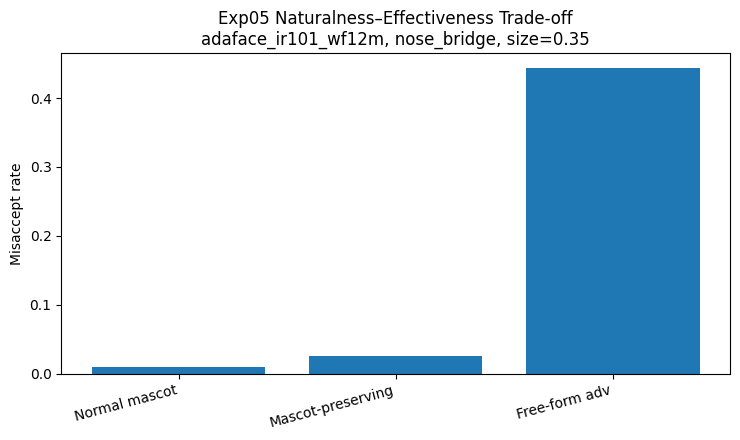

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/figures/05_tradeoff_similarity_drop.png


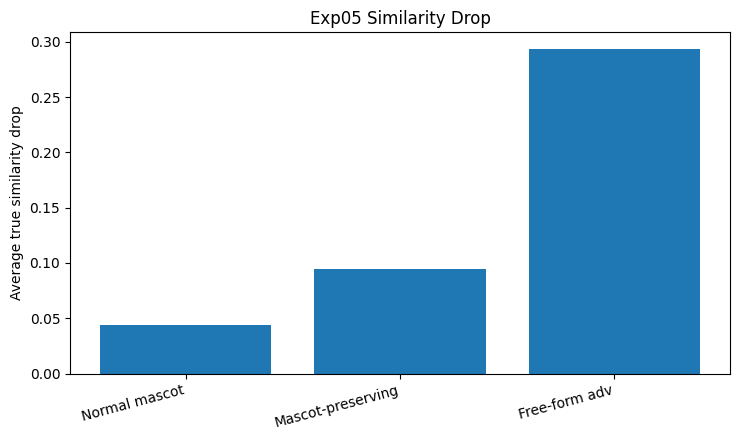

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/figures/05_naturalness_effectiveness_scatter.png


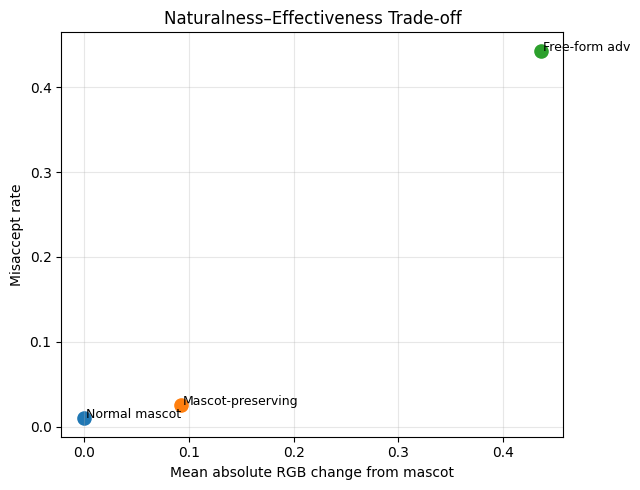

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/figures/05_patch_visual_comparison.png


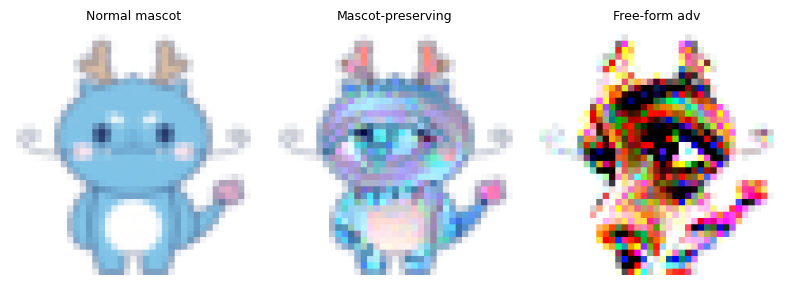

In [12]:
# ============================================================
# Cell 11. Exp05 Figures
# ============================================================

condition_order = [
    "normal_mascot_sticker",
    "mascot_preserving_constrained_patch",
    "free_form_adversarial_patch",
]

condition_labels = {
    "normal_mascot_sticker": "Normal mascot",
    "mascot_preserving_constrained_patch": "Mascot-preserving",
    "free_form_adversarial_patch": "Free-form adv",
}

plot_df = exp05_summary_df.copy()
plot_df["condition"] = pd.Categorical(
    plot_df["condition"],
    categories=condition_order,
    ordered=True,
)
plot_df = plot_df.sort_values("condition")
plot_df["label"] = plot_df["condition"].astype(str).map(condition_labels)


# ------------------------------------------------------------
# Figure 1. Misaccept rate
# ------------------------------------------------------------

plt.figure(figsize=(7.5, 4.5))
plt.bar(plot_df["label"], plot_df["misaccept_rate"])
plt.ylabel("Misaccept rate")
plt.title(
    f"Exp05 Naturalness–Effectiveness Trade-off\n"
    f"{MODEL_SHORT_NAME}, {EXP05_LOCATION}, size={EXP05_PATCH_SIZE_RATIO:.2f}"
)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

fig_path = EXP05_FIG_DIR / "05_tradeoff_misaccept_rate.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


# ------------------------------------------------------------
# Figure 2. Similarity drop
# ------------------------------------------------------------

plt.figure(figsize=(7.5, 4.5))
plt.bar(plot_df["label"], plot_df["avg_similarity_drop"])
plt.ylabel("Average true similarity drop")
plt.title("Exp05 Similarity Drop")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

fig_path = EXP05_FIG_DIR / "05_tradeoff_similarity_drop.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


# ------------------------------------------------------------
# Figure 3. Naturalness vs effectiveness
# x축: mascot과의 평균 RGB 변화량
# y축: misaccept rate
# ------------------------------------------------------------

plt.figure(figsize=(6.5, 5.0))

for _, row in plot_df.iterrows():
    plt.scatter(
        row["patch_mae_rgb_0_1"],
        row["misaccept_rate"],
        s=90,
    )
    plt.text(
        row["patch_mae_rgb_0_1"] + 0.002,
        row["misaccept_rate"],
        condition_labels[str(row["condition"])],
        fontsize=9,
    )

plt.xlabel("Mean absolute RGB change from mascot")
plt.ylabel("Misaccept rate")
plt.title("Naturalness–Effectiveness Trade-off")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = EXP05_FIG_DIR / "05_naturalness_effectiveness_scatter.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


# ------------------------------------------------------------
# Figure 4. Patch visual comparison
# ------------------------------------------------------------

patch_imgs = []
patch_titles = []

for cond in condition_order:
    patch_imgs.append(
        patch_to_display_pil(
            exp05_patches[cond],
            exp05_masks[cond],
            scale=5,
        )
    )
    patch_titles.append(condition_labels[cond])

show_pil_grid(
    patch_imgs,
    patch_titles,
    ncols=3,
    figsize=(8, 3),
    save_path=EXP05_FIG_DIR / "05_patch_visual_comparison.png",
)

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/figures/05_same_face_patch_type_grid.png


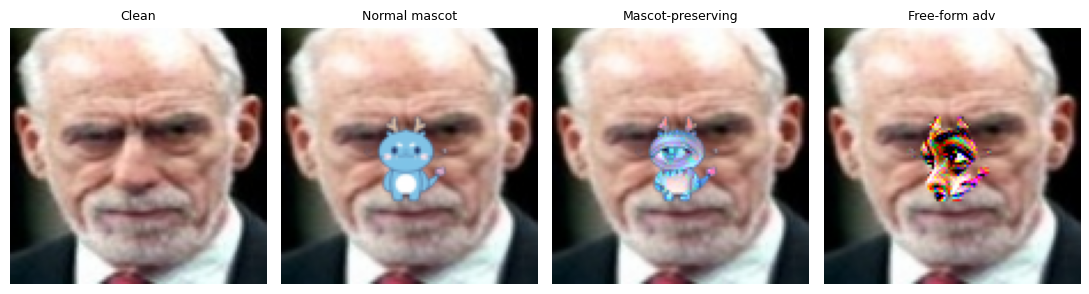

In [13]:
# ============================================================
# Cell 12. Exp05 Qualitative Grid
# Same face, different patch types
# ============================================================

# free-form에서 misaccept된 샘플 하나를 우선 사용한다.
free_detail = exp05_details["free_form_adversarial_patch"]

if len(free_detail[free_detail["misaccept"] == True]) > 0:
    sample_base_idx = int(
        free_detail[free_detail["misaccept"] == True]
        .sample(n=1, random_state=SEED)
        .iloc[0]["base_probe_row"]
    )
else:
    sample_base_idx = int(clean_eval_indices[0])

sample_item = probe_items[sample_base_idx]
sample_pil = sample_item["pil"]
sample_landmarks = sample_item.get("landmarks", CANONICAL_LANDMARKS_112)

imgs = [
    sample_pil.convert("RGB").resize((112, 112)),
]

titles = [
    "Clean",
]

for cond in condition_order:
    patched_img = add_patch_to_pil_for_visual(
        sample_pil,
        exp05_patches[cond],
        exp05_masks[cond],
        location=EXP05_LOCATION,
        landmarks=sample_landmarks,
    )

    imgs.append(patched_img)
    titles.append(condition_labels[cond])

show_pil_grid(
    imgs,
    titles,
    ncols=4,
    figsize=(11, 3.5),
    save_path=EXP05_FIG_DIR / "05_same_face_patch_type_grid.png",
)

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/figures/05_random_misaccept_examples_patch_type_comparison.png
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/05_random_misaccept_examples_metadata.csv


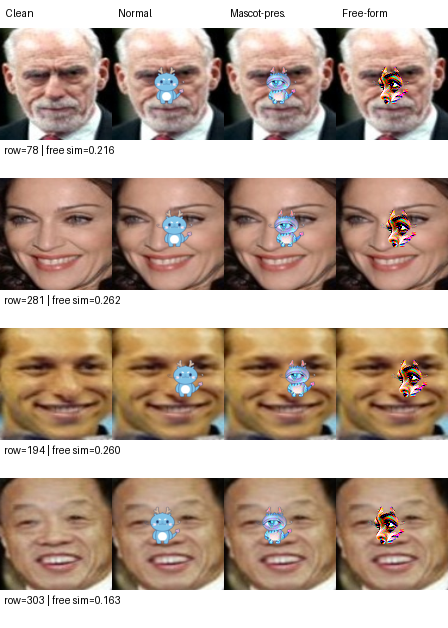

,base_probe_row,true_identity,free_form_top1_identity,free_form_top1_similarity,free_form_true_similarity,location,patch_size_ratio,patch_size_px,free_form_misaccept
0,78,David Anderson,Victoria Clarke,0.215934,-0.003047,nose_bridge,0.35,39,True
1,281,Madonna,Chanda Rubin,0.262099,0.075813,nose_bridge,0.35,39,True
2,194,Ian Thorpe,Chanda Rubin,0.259756,0.229361,nose_bridge,0.35,39,True
3,303,Li Zhaoxing,Victoria Clarke,0.162947,0.140079,nose_bridge,0.35,39,True


In [14]:
# ============================================================
# Cell 13. Exp05 Random Misaccept Examples
# Clean / normal / constrained / free-form
# ============================================================

QUAL_NUM_EXAMPLES = 4
QUAL_RANDOM_SEED = 42

# free-form이 가장 강할 가능성이 높으므로 free-form misaccept 샘플 기준으로 선택한다.
candidate_df = exp05_details["free_form_adversarial_patch"]
misaccept_df = candidate_df[candidate_df["misaccept"] == True].copy()

if len(misaccept_df) == 0:
    print("[WARN] free-form misaccept 샘플이 없어 misidentified 샘플로 대체한다.")
    misaccept_df = candidate_df[candidate_df["misidentified"] == True].copy()

sample_n = min(QUAL_NUM_EXAMPLES, len(misaccept_df))

if sample_n > 0:
    selected_df = misaccept_df.sample(
        n=sample_n,
        random_state=QUAL_RANDOM_SEED,
    ).reset_index(drop=True)

    cell_w = 112
    cell_h = 150
    header_h = 28
    ncols = 4
    nrows = sample_n

    canvas = Image.new(
        "RGB",
        (cell_w * ncols, header_h + cell_h * nrows),
        "white",
    )

    draw = ImageDraw.Draw(canvas)

    headers = [
        "Clean",
        "Normal",
        "Mascot-pres.",
        "Free-form",
    ]

    for c, h in enumerate(headers):
        draw.text(
            (cell_w * c + 6, 7),
            h,
            fill=(0, 0, 0),
        )

    metadata_rows = []

    for r, row in enumerate(selected_df.itertuples()):
        base_idx = int(row.base_probe_row)

        item = probe_items[base_idx]
        landmarks = item.get("landmarks", CANONICAL_LANDMARKS_112)

        clean_pil = item["pil"].convert("RGB").resize((112, 112))

        normal_pil = add_patch_to_pil_for_visual(
            item["pil"],
            exp05_patches["normal_mascot_sticker"],
            exp05_masks["normal_mascot_sticker"],
            location=EXP05_LOCATION,
            landmarks=landmarks,
        )

        constrained_pil = add_patch_to_pil_for_visual(
            item["pil"],
            exp05_patches["mascot_preserving_constrained_patch"],
            exp05_masks["mascot_preserving_constrained_patch"],
            location=EXP05_LOCATION,
            landmarks=landmarks,
        )

        free_pil = add_patch_to_pil_for_visual(
            item["pil"],
            exp05_patches["free_form_adversarial_patch"],
            exp05_masks["free_form_adversarial_patch"],
            location=EXP05_LOCATION,
            landmarks=landmarks,
        )

        y = header_h + r * cell_h

        canvas.paste(clean_pil, (cell_w * 0, y))
        canvas.paste(normal_pil, (cell_w * 1, y))
        canvas.paste(constrained_pil, (cell_w * 2, y))
        canvas.paste(free_pil, (cell_w * 3, y))

        caption = f"row={base_idx} | free sim={row.top1_similarity:.3f}"
        draw.text(
            (4, y + 116),
            caption,
            fill=(0, 0, 0),
        )

        metadata_rows.append({
            "base_probe_row": base_idx,
            "true_identity": row.identity,
            "free_form_top1_identity": row.top1_identity,
            "free_form_top1_similarity": float(row.top1_similarity),
            "free_form_true_similarity": float(row.true_similarity),
            "location": EXP05_LOCATION,
            "patch_size_ratio": EXP05_PATCH_SIZE_RATIO,
            "patch_size_px": EXP05_PATCH_SIZE_PX,
            "free_form_misaccept": bool(row.misaccept),
        })

    qual_path = EXP05_FIG_DIR / "05_random_misaccept_examples_patch_type_comparison.png"
    qual_meta_path = EXP05_DIR / "05_random_misaccept_examples_metadata.csv"

    canvas.save(qual_path)
    pd.DataFrame(metadata_rows).to_csv(qual_meta_path, index=False)

    print("Saved:", qual_path)
    print("Saved:", qual_meta_path)

    display(canvas)
    display(pd.DataFrame(metadata_rows))

else:
    print("[WARN] qualitative example로 사용할 샘플이 없습니다.")

In [15]:
# ============================================================
# Cell 14. Exp05 Output Check
# ============================================================

config = {
    "experiment": "exp05_freeform_vs_mascot_preserving_constrained",
    "model_name": MODEL_NAME,
    "model_short_name": MODEL_SHORT_NAME,
    "dataset": "Color LFW via sklearn.fetch_lfw_people",
    "num_identities": NUM_IDENTITIES,
    "target_far": TARGET_FAR,
    "location": EXP05_LOCATION,
    "patch_size_ratio": EXP05_PATCH_SIZE_RATIO,
    "patch_size_px": EXP05_PATCH_SIZE_PX,
    "constrain_eps_norm": EXP05_CONSTRAIN_EPS_NORM,
    "constrain_eps_rgb_0_1": EXP05_CONSTRAIN_EPS_NORM / 2.0,
    "preserve_weight": EXP05_PRESERVE_WEIGHT,
    "delta_tv_weight": EXP05_DELTA_TV_WEIGHT,
    "attack_steps": ATTACK_STEPS,
    "attack_batch_size": ATTACK_BATCH_SIZE,
    "attack_lr": ATTACK_LR,
    "threshold": float(threshold),
    "run_tag": RUN_TAG,
}

with open(EXP05_DIR / "05_exp05_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Exp05 done.")
print("EXP05_DIR:", EXP05_DIR)

print("\nKey files:")
print("-", EXP05_DIR / "05_freeform_vs_constrained_summary.csv")
print("-", EXP05_DIR / "05_patch_naturalness_metrics.csv")
print("-", EXP05_DIR / "05_exp05_config.json")
print("-", EXP05_FIG_DIR / "05_tradeoff_misaccept_rate.png")
print("-", EXP05_FIG_DIR / "05_tradeoff_similarity_drop.png")
print("-", EXP05_FIG_DIR / "05_naturalness_effectiveness_scatter.png")
print("-", EXP05_FIG_DIR / "05_patch_visual_comparison.png")
print("-", EXP05_FIG_DIR / "05_same_face_patch_type_grid.png")
print("-", EXP05_FIG_DIR / "05_random_misaccept_examples_patch_type_comparison.png")

print("\nAll saved files:")
for p in sorted(EXP05_DIR.rglob("*")):
    if p.is_file():
        print("-", p.relative_to(EXP05_DIR))

Exp05 done.
EXP05_DIR: /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained

Key files:
- /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/05_freeform_vs_constrained_summary.csv
- /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/05_patch_naturalness_metrics.csv
- /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/05_exp05_config.json
- /content/drive/MyDrive/SafeAI-final-project/output/exp05_freeform_vs_constrained_only_color_lfw/adaface_ir101_wf12m/run_20260615_145730/exp05_freeform_vs_constrained/figures/05_tradeoff_misaccept_rate